<a href="https://colab.research.google.com/github/gifeonu-PGee/enog-server/blob/main/Project_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Transfer Learning for Business Image Classification using MobileNetV2

In [2]:
!pip install -U protobuf tensorflow-datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 5.6 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.35.1 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.35.1 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.35.1 which is incompatible.


In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

 Load dataset (same as Project 02)

In [2]:
(train_ds, val_ds), metadata = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:]'],
    with_info=True,
    as_supervised=True,
)

print("Classes:", metadata.features['label'].names)

Classes: ['cat', 'dog']


MobileNetV2 expects 160×160 (or 224×224) images and pixel values scaled to [-1, 1], not [0, 1] — different from your custom CNN. There's a built-in preprocessing function for this.

In [3]:
IMG_SIZE = (160, 160)
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label

train_ds = train_ds.map(preprocess).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

What's happening here: include_top=False strips off MobileNet's original 1000-class ImageNet classifier, keeping only the feature-extraction layers. weights='imagenet' loads weights already trained to recognize edges, textures, shapes, and objects from 1.4 million real images. base_model.trainable = False freezes those weights so training doesn't destroy that pretrained knowledge — you're borrowing MobileNet's "vision," not re-teaching it from zero like you did with your CIFAR-10 and Cats-vs-Dogs CNNs.

In [4]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(160, 160, 3),
    include_top=False,      # exclude MobileNet's original classifier head
    weights='imagenet'      # pretrained on 1.4 million images
)

base_model.trainable = False  # freeze it — don't retrain these weights yet

base_model.summary()

Model: "mobilenetv2_1.00_160"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 80, 80,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 80, 80,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 80, 80,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 80, 80,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 80, 80,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 80, 80,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 81, 81,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 40, 40,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 40, 40,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [5]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')  # binary: cat vs dog
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

EPOCHS = 10

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds
)

Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 544s 910ms/step - accuracy: 0.8673 - loss: 0.3215 - val_accuracy: 0.9641 - val_loss: 0.1318
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 539s 923ms/step - accuracy: 0.9646 - loss: 0.1146 - val_accuracy: 0.9733 - val_loss: 0.0863
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 557s 953ms/step - accuracy: 0.9711 - loss: 0.0855 - val_accuracy: 0.9770 - val_loss: 0.0705
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 538s 922ms/step - accuracy: 0.9761 - loss: 0.0715 - val_accuracy: 0.9789 - val_loss: 0.0624
Epoch 5/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 503s 862ms/step - accuracy: 0.9786 - loss: 0.0641 - val_accuracy: 0.9809 - val_loss: 0.0574
Epoch 6/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 543s 931ms/step - accuracy: 0.9794 - loss: 0.0594 - val_accuracy: 0.9817 - val_loss: 0.0543
Epoch 7/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 494s 847ms/step - accuracy: 0.9794 - loss: 0.0577 - val_accuracy: 0.9826 - val_loss: 0.0522
Epoch 8/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 549s 940ms/step - accuracy: 0.9803 -

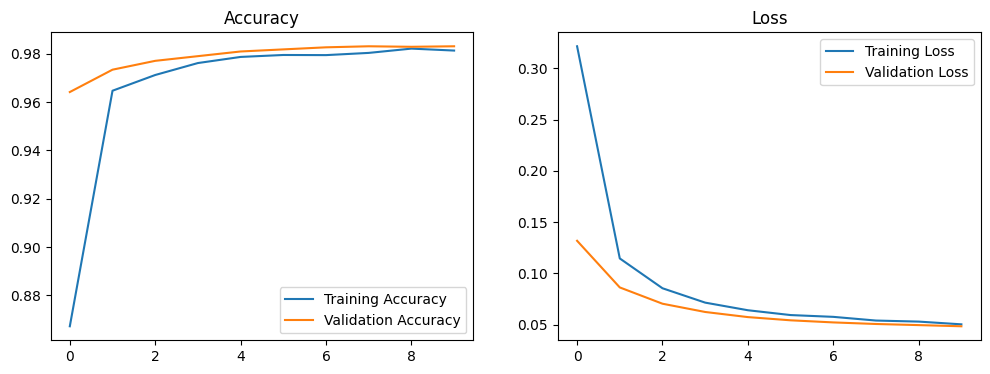

In [7]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()

In [8]:
from google.colab import files
from tensorflow.keras.preprocessing import image as keras_image
import numpy as np

uploaded = files.upload()

for fn in uploaded.keys():
    img = keras_image.load_img(fn, target_size=IMG_SIZE)
    img_array = keras_image.img_to_array(img)
    img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)[0][0]
    label = "Dog 🐶" if prediction > 0.5 else "Cat 🐱"
    confidence = prediction if prediction > 0.5 else 1 - prediction

    print(f"{fn}: {label} (confidence: {confidence:.2%})")

Saving Screenshot 2026-07-13 192943.png to Screenshot 2026-07-13 192943.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Screenshot 2026-07-13 192943.png: Dog 🐶 (confidence: 99.73%)


In [9]:
base_model.trainable = True

# MobileNetV2 has ~154 layers. Freeze everything except the last ~30.
fine_tune_at = len(base_model.layers) - 30

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f"Total layers: {len(base_model.layers)}")
print(f"Trainable from layer {fine_tune_at} onward")

Total layers: 154
Trainable from layer 124 onward


In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),  # 10x lower than before
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,527,681 (5.83 MB)

 Non-trainable params: 731,584 (2.79 MB)

In [11]:
FINE_TUNE_EPOCHS = 10
TOTAL_EPOCHS = EPOCHS + FINE_TUNE_EPOCHS

history_fine = model.fit(
    train_ds,
    epochs=TOTAL_EPOCHS,
    initial_epoch=history.epoch[-1] + 1,   # continue numbering from where Cell 6 left off
    validation_data=val_ds
)

Epoch 11/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 693s 1s/step - accuracy: 0.9512 - loss: 0.1229 - val_accuracy: 0.9766 - val_loss: 0.0744
Epoch 12/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 698s 1s/step - accuracy: 0.9731 - loss: 0.0662 - val_accuracy: 0.9813 - val_loss: 0.0579
Epoch 13/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 647s 1s/step - accuracy: 0.9788 - loss: 0.0555 - val_accuracy: 0.9830 - val_loss: 0.0493
Epoch 14/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 633s 1s/step - accuracy: 0.9826 - loss: 0.0487 - val_accuracy: 0.9826 - val_loss: 0.0482
Epoch 15/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 649s 1s/step - accuracy: 0.9864 - loss: 0.0384 - val_accuracy: 0.9837 - val_loss: 0.0459
Epoch 16/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 636s 1s/step - accuracy: 0.9881 - loss: 0.0331 - val_accuracy: 0.9837 - val_loss: 0.0469
Epoch 17/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 614s 972ms/step - accuracy: 0.9905 - loss: 0.0271 - val_accuracy: 0.9828 - val_loss: 0.0481
Epoch 18/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 625s 977ms/step - accuracy: 0.9918 - loss: 0.0

In [ ]:
acc += history_fine.history['accuracy']
val_acc += history_fine.history['val_accuracy']
loss += history_fine.history['loss']
val_loss += history_fine.history['val_loss']

epochs_range = range(TOTAL_EPOCHS)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.axvline(x=EPOCHS-1, color='gray', linestyle='--', label='Fine-tuning starts')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.axvline(x=EPOCHS-1, color='gray', linestyle='--', label='Fine-tuning starts')
plt.legend()
plt.title('Loss')

plt.show()

In [12]:
model.save("project03_mobilenet_cats_dogs.keras")

print("Model saved successfully.")

Model saved successfully.
